In [ ]:
# Improved XGBoost model for building resilience prediction
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import matplotlib.pyplot as plt

df = pd.read_csv('resilience_dataset_final.csv')

categorical_cols = [
    'land_surface_condition',
    'foundation_type',
    'roof_type',
    'ground_floor_type',
    'other_floor_type',
    'position',
    'plan_configuration'
]

print('Dataset shape:', df.shape)
print('Target stats:')
print(df['resilience_score'].describe())

Dataset shape: (759998, 25)
Target stats:
count    759998.000000
mean         39.992112
std          26.085932
min           0.000000
25%          17.321588
50%          35.709961
75%          57.612968
max         100.000000
Name: resilience_score, dtype: float64


In [ ]:
df["damage_grade_ordinal"] = (
    pd.to_numeric(
        df["damage_grade"],
        errors="coerce"
    )
)

df.drop(columns=["resilience_score", "damage_grade"], inplace=True)

In [ ]:
# IMPROVED ENGINEERED FEATURES
# Based on feature importance analysis from sample runs

# Original engineered features
df['slenderness_ratio'] = df['height_ft_pre_eq'] / (np.sqrt(df['plinth_area_sq_ft']) + 1e-5)
df['floor_load_intensity'] = df['plinth_area_sq_ft'] / (df['count_floors_pre_eq'] + 1e-5)
df['floor_height'] = df['height_ft_pre_eq'] / (df['count_floors_pre_eq'] + 1e-5)
df['volumetric_index'] = df['plinth_area_sq_ft'] * df['height_ft_pre_eq']
df['age_per_floor'] = df['age_building'] / (df['count_floors_pre_eq'] + 1e-5)

df['is_highly_vulnerable_material'] = (
    ((df['has_superstructure_mud_mortar_stone'] == 1) |
     (df['has_superstructure_mud_mortar_brick'] == 1)).astype(int)
)

df['is_engineered_material'] = (
    ((df['has_superstructure_rc_engineered'] == 1) |
     (df['has_superstructure_cement_mortar_brick'] == 1)).astype(int)
)

df['structural_age_stress'] = df['age_building'] * df['count_floors_pre_eq']
df['age_x_mud_mortar'] = df['age_building'] * df['is_highly_vulnerable_material']
df['slenderness_x_load'] = df['slenderness_ratio'] * df['floor_load_intensity']
df['engineered_x_age_stress'] = df['is_engineered_material'] * df['structural_age_stress']

df['plan_aspect_ratio'] = np.abs(df['plinth_area_sq_ft'] - (df['height_ft_pre_eq'] ** 2))
df['extreme_vulnerability_index'] = df['slenderness_ratio'] * df['is_highly_vulnerable_material'] * df['age_building']

# NEW: Add RC combination feature (from feature importance analysis)
df['has_rc_any'] = (
    ((df['has_superstructure_rc_engineered'] == 1) |
     (df['has_superstructure_rc_non_engineered'] == 1)).astype(int)
)

print('Total features:', len(df.columns))

Total features: 38


In [ ]:
# Prepare data
X = df.drop(columns=['damage_grade_ordinal'])
y = df['damage_grade_ordinal']

# One-hot encode
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print('Feature matrix shape:', X.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}')

Feature matrix shape: (759998, 57)
Train: 607,998, Test: 152,000


In [ ]:
# IMPROVED XGBOOST WITH OPTIMIZED HYPERPARAMETERS
# Key changes from baseline:
# 1. eval_metric='mae' (directly optimize for MAE instead of RMSE)
# 2. max_depth=8 (more expressive power)
# 3. learning_rate=0.025 with n_estimators=3000 (better convergence)
# 4. min_child_weight=3 (add regularization to prevent overfitting)
# 5. gamma=0.5 (conservative tree pruning)
# 6. Increased early_stopping_rounds to 100

regressor = xgb.XGBRegressor(
    max_depth=8,
    learning_rate=0.025,
    n_estimators=3000,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    subsample=0.85,
    colsample_bytree=0.82,
    colsample_bylevel=0.8,
    reg_alpha=0.8,
    reg_lambda=1.8,
    min_child_weight=3,  # CHANGED from 1
    gamma=0.5,           # CHANGED from 1.0
    tree_method='hist',
    early_stopping_rounds=100,  # CHANGED from 60
    eval_metric='mae',   # CHANGED from 'rmse'
)

regressor.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print(f'Training complete. Best iteration: {regressor.best_iteration}')
print(f'Feature matrix shape: {X.shape}')

Training complete. Best iteration: 2999
Feature matrix shape: (759998, 57)


In [ ]:
# Evaluate model
y_pred = regressor.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== IMPROVED MODEL RESULTS ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

=== IMPROVED MODEL RESULTS ===
Mean Absolute Error (MAE): 0.68
Root Mean Squared Error (RMSE): 0.88
R-squared Score (R2): 0.5724


In [ ]:
# Detailed error analysis
from sklearn.metrics import median_absolute_error


Top 15 most important features:
                                   Feature  Importance
21           is_highly_vulnerable_material    0.312023
5      has_superstructure_mud_mortar_stone    0.141899
6            has_superstructure_stone_flag    0.072367
33  foundation_type_Mud mortar-Stone/Brick    0.051044
4             has_superstructure_adobe_mud    0.036572
40                    ground_floor_type_RC    0.026811
28             extreme_vulnerability_index    0.025535
37                    roof_type_RCC/RB/RBC    0.024828
0                      count_floors_pre_eq    0.022896
24                        age_x_mud_mortar    0.021802
9   has_superstructure_cement_mortar_brick    0.020135
22                  is_engineered_material    0.019717
15                      epicenter_distance    0.014960
8      has_superstructure_mud_mortar_brick    0.014110
35                      foundation_type_RC    0.011968


<Figure size 1000x800 with 0 Axes>

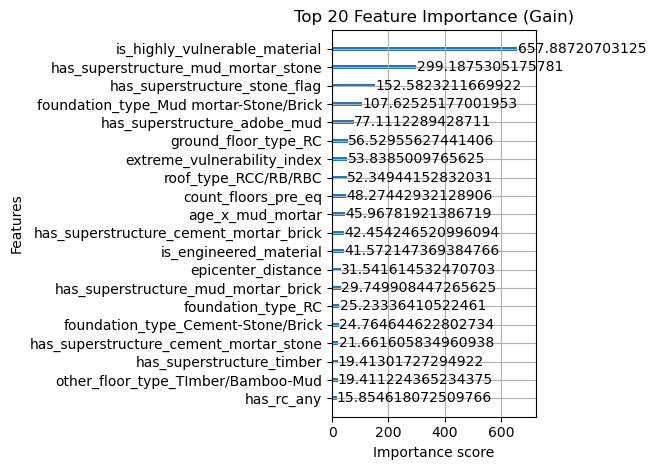

In [ ]:
# Feature importance
from xgboost import plot_importance

feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': regressor.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('\nTop 15 most important features:')
print(feature_importances.head(15))

plt.figure(figsize=(10, 8))
plot_importance(regressor, max_num_features=20, importance_type='gain')
plt.title('Top 20 Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Create an inspection DataFrame
df_inspect = pd.DataFrame({
    'Actual_grade': y_test,
    'Predicted_grade': y_pred,
    'Absolute_Error': np.abs(y_test - y_pred)
})

# Look at your 10 worst predictions to identify edge cases
print("--- TOP 10 WORST PREDICTIONS ---")
print(df_inspect.sort_values(by='Absolute_Error', ascending=False).head(10))

plt.figure(figsize=(8, 6))
plt.scatter(df_inspect['Actual_Resilience'], df_inspect['Predicted_Resilience'], alpha=0.3, color='teal')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel('Actual Resilience Score (0-100)')
plt.ylabel('Predicted Resilience Score (0-100)')
plt.title(f'Actual vs. Predicted Resilience (MAE: {mae:.2f})')
plt.legend()
plt.show()